In [2]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd

ARCHIVE = Path("../archive")     # study_hyeock 폴더 기준으로 한 칸 위
BATCH_FILES = {
    "B1": ARCHIVE / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",  # Train
    "B2": ARCHIVE / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",  # Test 1
    "B3": ARCHIVE / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",  # Test 2
}
for b, p in BATCH_FILES.items():
    print(b, p.name, f"{p.stat().st_size/1e9:.2f} GB", "✅" if p.exists() else "❌")

B1 2017-05-12_batchdata_updated_struct_errorcorrect.mat 3.03 GB ✅
B2 2018-02-20_batchdata_updated_struct_errorcorrect.mat 2.02 GB ✅
B3 2018-04-12_batchdata_updated_struct_errorcorrect.mat 3.24 GB ✅


In [19]:
%config InlineBackend.figure_format = "retina"   # 맥 화면 해상도로 선명하게
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

In [3]:
f = h5py.File(BATCH_FILES["B1"], "r")    # "r" = 읽기 전용 (원본 보호)

# ① 최상위 선반
print("① 최상위:", list(f.keys()))
batch = f["batch"]
print("   batch 안:", list(batch.keys()))
print("   summary 쪽지 배열 shape:", batch["summary"].shape)   # (셀 수, 1)

# ② 쪽지 → 실제 데이터 따라가기 (0번 셀)
ref = batch["summary"][0, 0]
print("\n② 쪽지의 정체:", type(ref).__name__)
summary0 = f[ref]                           # 쪽지를 따라가면 Group이 나옴
print("   summary 안의 키:", list(summary0.keys()))
qd = summary0["QDischarge"][()].ravel()     # [()] 순간 디스크에서 읽음
print("   QDischarge 개수:", qd.shape, "| 앞 5개:", qd[:5].round(4))

# ③ 셀 하나의 스칼라 정보
cycle_life = f[batch["cycle_life"][0, 0]][()].item()
policy_raw = f[batch["policy_readable"][0, 0]][()].ravel()
print("\n③ cycle_life:", cycle_life)
print("   policy 원본(숫자):", policy_raw[:6])
print("   policy 문자로 변환:", "".join(chr(c) for c in policy_raw))

# ④ cycles: 사이클 내부 시계열 (쪽지 안에 또 쪽지)
cyc0 = f[batch["cycles"][0, 0]]
print("\n④ cycles 안의 키:", list(cyc0.keys()))
print("   Qdlin 쪽지 배열 shape:", cyc0["Qdlin"].shape)
for k in [0, 1, 2, 10, 100]:
    arr = f[cyc0["Qdlin"][k, 0]][()].ravel()
    print(f"   Qdlin[{k:>3}] 길이 = {arr.size}")

① 최상위: ['#refs#', '#subsystem#', 'batch', 'batch_date']
   batch 안: ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']
   summary 쪽지 배열 shape: (46, 1)

② 쪽지의 정체: Reference
   summary 안의 키: ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
   QDischarge 개수: (1189,) | 앞 5개: [0.     1.0707 1.0719 1.0725 1.0732]

③ cycle_life: 1190.0
   policy 원본(숫자): [51 46 54 67 40 56]
   policy 문자로 변환: 3.6C(80%)-3.6C

④ cycles 안의 키: ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
   Qdlin 쪽지 배열 shape: (1189, 1)
   Qdlin[  0] 길이 = 2
   Qdlin[  1] 길이 = 1000
   Qdlin[  2] 길이 = 1000
   Qdlin[ 10] 길이 = 1000
   Qdlin[100] 길이 = 1000


코드 ① 세 배치 불러와서 합치기

In [4]:
f.close()   # 아까 열어둔 창고 문 닫기

def mat_str(f, ref):
    """MATLAB 글자(숫자 배열) → 파이썬 글자"""
    return "".join(chr(c) for c in f[ref][()].ravel())

def load_batch_summary(batch_name, path):
    """배치 하나의 모든 배터리 일기장을 표 하나로"""
    tables = []
    with h5py.File(path, "r") as f:            # with: 다 쓰면 문을 자동으로 닫아줌
        b = f["batch"]
        for i in range(b["summary"].shape[0]):  # 배터리 한 개씩
            s = f[b["summary"][i, 0]]
            df = pd.DataFrame({k: s[k][()].ravel() for k in s.keys()})
            df["batch"] = batch_name
            df["cell_id"] = f"{batch_name}_{i:02d}"      # 반 이름 + 번호
            df["policy"] = mat_str(f, b["policy_readable"][i, 0])
            df["cycle_life"] = f[b["cycle_life"][i, 0]][()].item()
            tables.append(df)
    return pd.concat(tables, ignore_index=True)

raw = pd.concat(
    [load_batch_summary(b, p) for b, p in BATCH_FILES.items()],
    ignore_index=True,
)
raw["cycle"] = raw["cycle"].astype(int)
print("합친 표 크기:", raw.shape)
print(raw.groupby("batch")["cell_id"].nunique())

합친 표 크기: (116722, 12)
batch
B1    46
B2    47
B3    46
Name: cell_id, dtype: int64


코드 ② 청소하기 (규칙 2개)

In [5]:
# 규칙 1: 1번째 사이클 빼기 (키를 안 잰 날 = 0)
df = raw[raw["cycle"] > 1].copy()

# 규칙 2: 수명(정답)이 없는 배터리 빼기
nan_cells = (raw.loc[raw["cycle_life"].isna(), ["batch", "cell_id", "policy"]]
                .drop_duplicates())
print("정답이 없는 배터리:")
print(nan_cells.to_string(index=False))
df = df[df["cycle_life"].notna()].copy()

print("\n청소 전:", raw.shape[0], "줄 → 청소 후:", df.shape[0], "줄")

정답이 없는 배터리:
batch cell_id                      policy
   B2   B2_22      VarCharge-2C-100cycles
   B2   B2_23      VarCharge-4C-100cycles
   B2   B2_35      VarCharge-6C-100cycles
   B2   B2_36      VarCharge-8C-100cycles
   B2   B2_37    3.6C(80%)-3.6C(SLOWCYCLE
   B2   B2_38    4.8C(80%)-4.8C(SLOWCYCLE
   B2   B2_39       3.6C(9%)-5C(SLOWCYCLE
   B2   B2_40      5.2C(58%)-4C(SLOWCYCLE
   B3   B3_23 4.8C(80%)-4.8C-newstructure
   B3   B3_32 4.8C(80%)-4.8C-newstructure

청소 전: 116722 줄 → 청소 후: 108297 줄


코드 ③ 배터리 명단 만들고 저장하기

In [6]:
cells = (df.groupby("cell_id")
           .agg(batch=("batch", "first"),
                policy=("policy", "first"),
                cycle_life=("cycle_life", "first"),
                last_cycle=("cycle", "max"))
           .reset_index())
print(cells.groupby("batch").size())    # 기대값: B1 46, B2 39, B3 44
cells.head()

# 저장 → 다음부터는 3GB 창고 대신 이 작은 파일만 읽으면 끝!
Path("processed").mkdir(exist_ok=True)
df.to_parquet("processed/summary.parquet", index=False)
cells.to_parquet("processed/cells.parquet", index=False)
print("저장 완료 ✅")

batch
B1    46
B2    39
B3    44
dtype: int64
저장 완료 ✅


Lesson 2. Q1 수명 분포

코드 ① 준비 + 배치별 통계표

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.family"] = "AppleGothic"     # 맥 한글 폰트
plt.rcParams["axes.unicode_minus"] = False

cells = pd.read_parquet("processed/cells.parquet")
df = pd.read_parquet("processed/summary.parquet")
cells["log_life"] = np.log(cells["cycle_life"])

g = cells.groupby("batch")["cycle_life"]
stats = pd.DataFrame({
    "n": g.size(),
    "min": g.min(), "Q1": g.quantile(.25), "median": g.median(),
    "mean": g.mean(), "Q3": g.quantile(.75), "max": g.max(),
    "std": g.std(),
    "CV": g.std() / g.mean(),
    "IQR": g.quantile(.75) - g.quantile(.25),
    "skew": g.skew(),
    "kurt": g.apply(lambda s: s.kurt()),
    "skew(log)": cells.groupby("batch")["log_life"].skew(),
}).round(2)
stats

,n,min,Q1,median,mean,Q3,max,std,CV,IQR,skew,kurt,skew(log)
batch,,,,,,,,,,,,,
B1,46,534.0,703.25,858.5,844.72,914.25,1227.0,184.63,0.22,211.00,0.45,-0.48,0.04
B2,39,392.0,439.50,472.0,565.74,508.50,1186.0,222.20,0.39,69.00,1.64,1.45,1.36
B3,44,541.0,828.00,1005.5,1059.66,1155.25,1935.0,313.87,0.30,327.25,1.26,1.33,0.52


코드 ② 장수명 / 단수명 비율표

In [8]:
cells["life_group"] = pd.cut(cells["cycle_life"],
                             bins=[0, 500, 1000, np.inf],
                             labels=["단수명(<500)", "중간", "장수명(>1000)"])
ratio = pd.crosstab(cells["batch"], cells["life_group"], normalize="index").round(2)
ratio

life_group,단수명(<500),중간,장수명(>1000)
batch,,,
B1,0.00,0.78,0.22
B2,0.72,0.21,0.08
B3,0.00,0.48,0.52


/var/folders/c6/4665xq2d1nb0mbh02s6jmspr0000gn/T/ipykernel_54524/3810208339.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cells, x="batch", y="cycle_life", palette=colors, ax=axes[1])


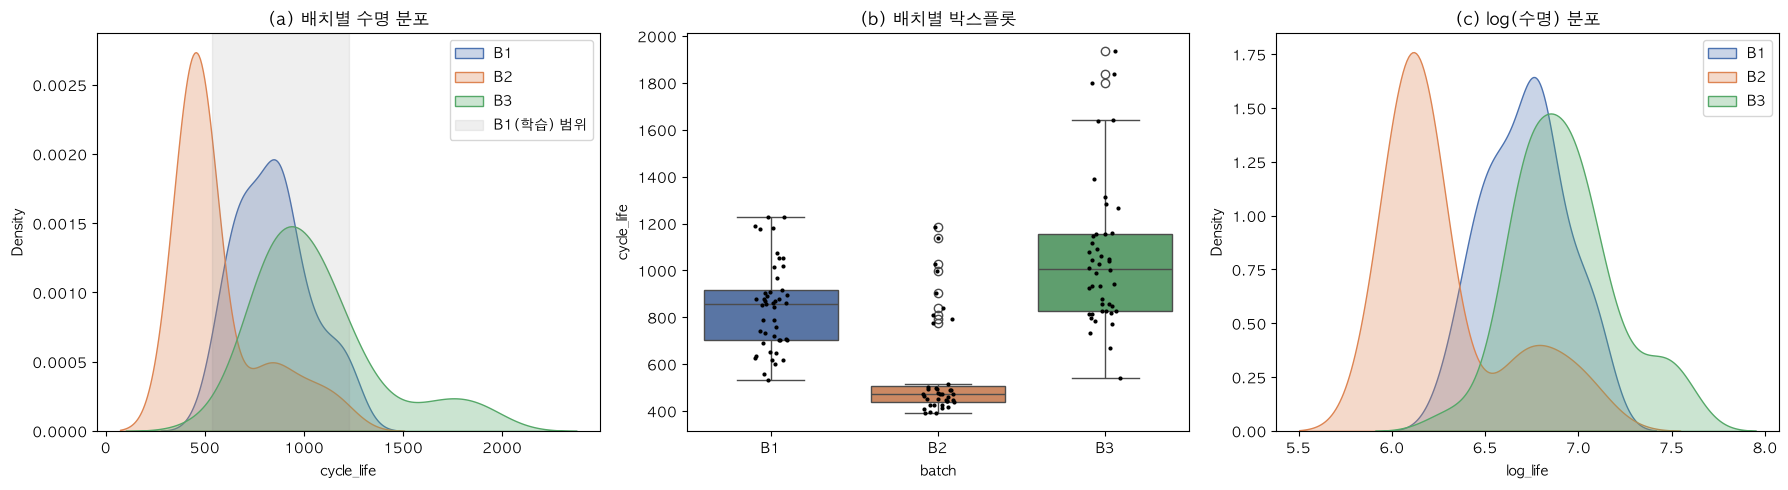

In [9]:
colors = {"B1": "#4C72B0", "B2": "#DD8452", "B3": "#55A868"}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) 원래 수명 분포
for b, c in colors.items():
    sns.kdeplot(cells.loc[cells.batch == b, "cycle_life"], ax=axes[0],
                fill=True, alpha=.3, color=c, label=b)
b1 = cells.loc[cells.batch == "B1", "cycle_life"]
axes[0].axvspan(b1.min(), b1.max(), color="gray", alpha=.12, label="B1(학습) 범위")
axes[0].set_title("(a) 배치별 수명 분포")
axes[0].legend()

# (b) 박스플롯
sns.boxplot(data=cells, x="batch", y="cycle_life", palette=colors, ax=axes[1])
sns.stripplot(data=cells, x="batch", y="cycle_life", color="k", size=3, ax=axes[1])
axes[1].set_title("(b) 배치별 박스플롯")

# (c) log 변환 후
for b, c in colors.items():
    sns.kdeplot(cells.loc[cells.batch == b, "log_life"], ax=axes[2],
                fill=True, alpha=.3, color=c, label=b)
axes[2].set_title("(c) log(수명) 분포")
axes[2].legend()

plt.tight_layout(); plt.show()

In [10]:
# 배치 안에서 IQR 규칙으로 이상치 찾기
def iqr_outlier(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    return (s < q1 - 1.5*(q3-q1)) | (s > q3 + 1.5*(q3-q1))
cells["outlier"] = cells.groupby("batch")["cycle_life"].transform(iqr_outlier)

# 초기 100사이클의 체온·충전시간을 붙여서 비교
early = (df[df.cycle <= 100].groupby("cell_id")
           .agg(Tavg_mean=("Tavg", "mean"), chargetime_mean=("chargetime", "mean"))
           .reset_index())
cells = cells.merge(early, on="cell_id", how="left")

print("🔎 이상치 배터리")
print(cells[cells.outlier][["cell_id", "policy", "cycle_life",
                            "Tavg_mean", "chargetime_mean"]].to_string(index=False))
print("\n📏 비교용: 배치별 평균")
print(cells.groupby("batch")[["cycle_life", "Tavg_mean", "chargetime_mean"]].mean().round(2))

🔎 이상치 배터리
cell_id                      policy  cycle_life  Tavg_mean  chargetime_mean
  B2_07 4.8C(80%)-4.8C-newstructure       777.0  33.769687        10.035778
  B2_08   5.2C(58%)-4C-newstructure       904.0  33.598684        10.039870
  B2_09 5.6C(26%)-4.5C-newstructure       791.0  32.350853        10.039929
  B2_32 4.8C(80%)-4.8C-newstructure       809.0  32.168949        49.671438
  B2_33   5.2C(58%)-4C-newstructure      1140.0  32.741571        10.039564
  B2_34 5.6C(26%)-4.5C-newstructure      1186.0  35.667891        49.677640
  B2_43 4.8C(80%)-4.8C-newstructure      1029.0  33.929145        10.036751
  B2_44   5.2C(58%)-4C-newstructure       841.0  33.959958        49.661380
  B2_45 5.6C(26%)-4.5C-newstructure       997.0  35.271412        10.040191
  B3_07 4.8C(80%)-4.8C-newstructure      1836.0  32.796945        11.040740
  B3_38     5C(67%)-4C-newstructure      1935.0  34.745836        10.043708
  B3_45 4.8C(80%)-4.8C-newstructure      1801.0  32.725964        11.038588

📏

# 열화곡선

🧒 개념
SOH = 지금 체력 ÷ 처음 설계 체력(1.1Ah). 80%(0.8)가 되면 "은퇴"예요.
Knee point(무릎 지점) = 천천히 늙다가 갑자기 확 늙기 시작하는 순간이에요. 미끄럼틀 위에서 평평하게 걷다가 경사가 확 꺾이는 곳이요. 찾는 방법은 간단해요. 곡선에 자 두 개를 대보고, 두 자가 곡선에 제일 잘 맞는 꺾이는 위치를 찾는 거예요.

코드 ① SOH 계산 + 배치별 곡선

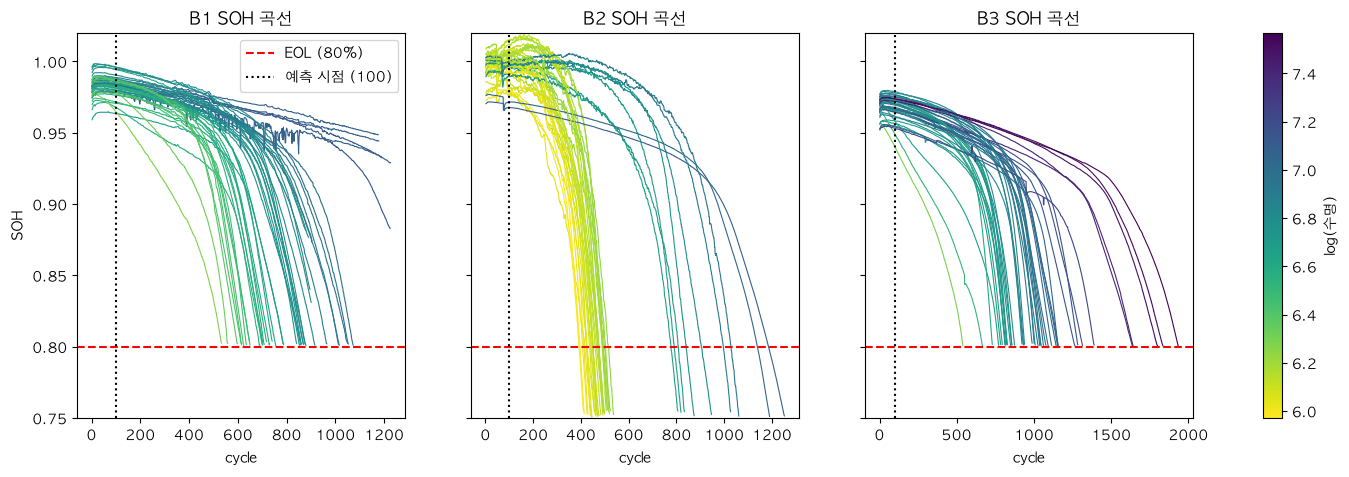

In [11]:
import matplotlib as mpl

df["SOH"] = df["QDischarge"] / 1.1
# 튀는 값 정리: 앞뒤 5개의 중앙값으로 부드럽게
df["SOH_s"] = df.groupby("cell_id")["SOH"].transform(
    lambda s: s.rolling(5, center=True, min_periods=1).median())

life = cells.set_index("cell_id")["log_life"]
norm = mpl.colors.Normalize(life.min(), life.max())
cmap = plt.cm.viridis_r      # 노랑 = 단수명, 보라 = 장수명

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, ["B1", "B2", "B3"]):
    for cid, g in df[df.batch == b].groupby("cell_id"):
        ax.plot(g.cycle, g.SOH_s, color=cmap(norm(life[cid])), lw=.8)
    ax.axhline(0.8, color="red", ls="--", label="EOL (80%)")
    ax.axvline(100, color="k", ls=":", label="예측 시점 (100)")
    ax.set_title(f"{b} SOH 곡선"); ax.set_xlabel("cycle"); ax.set_ylim(.75, 1.02)
axes[0].set_ylabel("SOH"); axes[0].legend()
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label="log(수명)")
plt.show()

코드 ② 100사이클 시점에 차이가 보이나?

In [13]:
soh = df.pivot_table(index="cell_id", columns="cycle", values="SOH_s")
cells["SOH_2"] = cells.cell_id.map(soh[2])
cells["SOH_100"] = cells.cell_id.map(soh[100])
cells["fade_2_100"] = cells["SOH_2"] - cells["SOH_100"]     # 100사이클 동안 줄어든 체력

print(cells.groupby("batch")[["SOH_100", "fade_2_100"]].agg(["mean", "std"]).round(4))
b1 = cells[cells.batch == "B1"]
print("\nB1: SOH_100 vs log(수명) 상관 =", round(b1.SOH_100.corr(b1.log_life), 3))
print("B1: fade_2_100 vs log(수명) 상관 =", round(b1.fade_2_100.corr(b1.log_life), 3))

      SOH_100         fade_2_100        
         mean     std       mean     std
batch                                   
B1     0.9824  0.0071    -0.0013  0.0027
B2     0.9962  0.0113    -0.0018  0.0058
B3     0.9672  0.0083     0.0004  0.0043

B1: SOH_100 vs log(수명) 상관 = 0.324
B1: fade_2_100 vs log(수명) 상관 = -0.602


코드 ③ Knee point 찾기 (자 두 개 대보기)

        knee  knee_ratio  accel
batch                          
B1     603.0        0.75   9.77
B2     342.0        0.75  11.56
B3     820.0        0.79   9.98


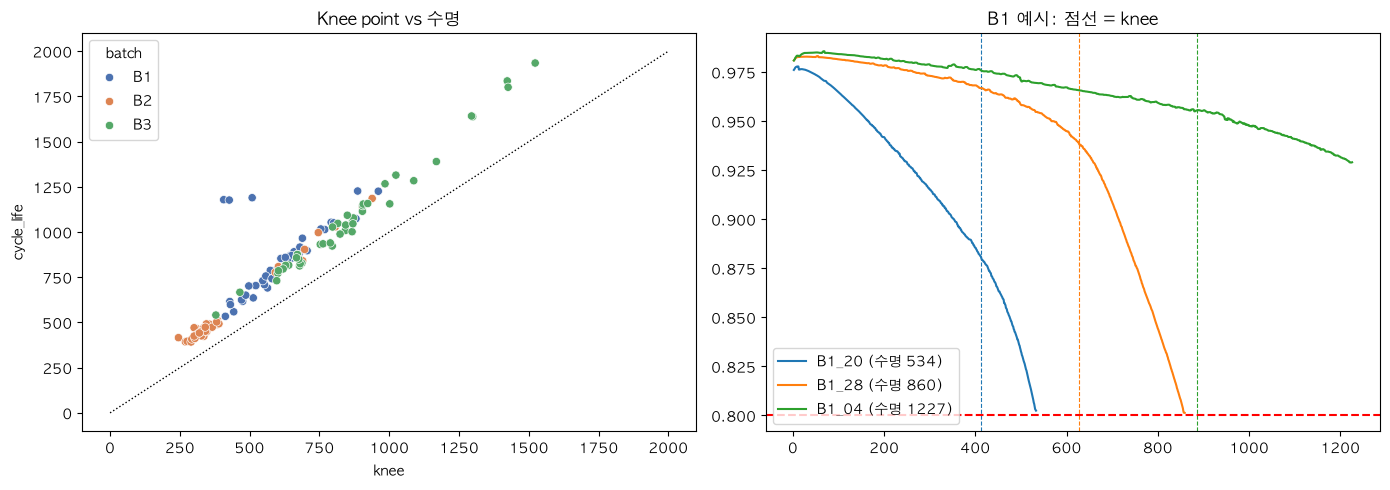

In [14]:
def knee_point(x, y, step=5):
    """곡선을 두 직선으로 나눴을 때 오차가 가장 작은 꺾임 위치"""
    best_sse, best = np.inf, None
    for k in range(int(len(x)*.2), int(len(x)*.95), step):
        p1, p2 = np.polyfit(x[:k], y[:k], 1), np.polyfit(x[k:], y[k:], 1)
        sse = ((np.polyval(p1, x[:k]) - y[:k])**2).sum() + ((np.polyval(p2, x[k:]) - y[k:])**2).sum()
        if sse < best_sse:
            best_sse, best = sse, (x[k], p1[0], p2[0])   # (꺾인 위치, 앞 기울기, 뒤 기울기)
    return best

rows = []
for cid, g in df.groupby("cell_id"):
    g = g[g.cycle <= cells.set_index("cell_id").loc[cid, "cycle_life"]]   # 은퇴 전까지만
    k, s1, s2 = knee_point(g.cycle.values, g.SOH_s.values)
    rows.append({"cell_id": cid, "knee": k, "slope_before": s1, "slope_after": s2})
cells = cells.merge(pd.DataFrame(rows), on="cell_id")
cells["knee_ratio"] = cells.knee / cells.cycle_life          # 수명의 몇 % 지점에서 꺾이나
cells["accel"] = cells.slope_after / cells.slope_before      # 꺾인 뒤 몇 배 빨리 늙나

print(cells.groupby("batch")[["knee", "knee_ratio", "accel"]].median().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=cells, x="knee", y="cycle_life", hue="batch", palette=colors, ax=axes[0])
axes[0].plot([0, 2000], [0, 2000], "k:", lw=1)
axes[0].set_title("Knee point vs 수명")
ex = cells[cells.batch == "B1"].sort_values("cycle_life").iloc[[0, 23, -1]]   # 단·중·장수명 예시
for _, r in ex.iterrows():
    g = df[(df.cell_id == r.cell_id) & (df.cycle <= r.cycle_life)]
    axes[1].plot(g.cycle, g.SOH_s, label=f"{r.cell_id} (수명 {r.cycle_life:.0f})")
    axes[1].axvline(r.knee, ls="--", lw=.8, color=axes[1].lines[-1].get_color())
axes[1].axhline(.8, color="red", ls="--"); axes[1].legend(); axes[1].set_title("B1 예시: 점선 = knee")
plt.tight_layout(); plt.show()

Lesson 4. Q3 ΔQ(V)

🧒 ΔQ(V) = 100번째 날 방전 곡선 − 10번째 날 방전 곡선. 체력(용량)은 거의 같아도 숨 쉬는 패턴이 먼저 바뀌는데, 그 차이를 보는 거예요.

In [21]:
# 1) 지금 cells에 dQ 관련 열이 어떻게 있는지 확인
print("현재 dQ 열:", [c for c in cells.columns if c.startswith("dQ")])

# 2) ΔQ 피처 다시 계산
dqf = pd.DataFrame([
    {"cell_id": cid, **dq_feats(d[100] - d[10], "dQ"), **dq_feats(d[5] - d[4], "dQ54")}
    for cid, d in Q.items()
])

# 3) 기존 dQ 열(+ _x/_y 찌꺼기) 싹 지우고 다시 붙이기
drop = [c for c in cells.columns if c.startswith("dQ")]
cells = cells.drop(columns=drop).merge(dqf, on="cell_id")
print("정리 후 dQ 열:", [c for c in cells.columns if c.startswith("dQ")])

현재 dQ 열: ['dQ_logvar_x', 'dQ_logmin_x', 'dQ_mean_x', 'dQ_skew_x', 'dQ_kurt_x', 'dQ54_logvar_x', 'dQ54_logmin_x', 'dQ54_mean_x', 'dQ54_skew_x', 'dQ54_kurt_x', 'dQ_logvar_y', 'dQ_logmin_y', 'dQ_mean_y', 'dQ_skew_y', 'dQ_kurt_y', 'dQ54_logvar_y', 'dQ54_logmin_y', 'dQ54_mean_y', 'dQ54_skew_y', 'dQ54_kurt_y']
정리 후 dQ 열: ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'dQ_kurt', 'dQ54_logvar', 'dQ54_logmin', 'dQ54_mean', 'dQ54_skew', 'dQ54_kurt']


셀 수: 129


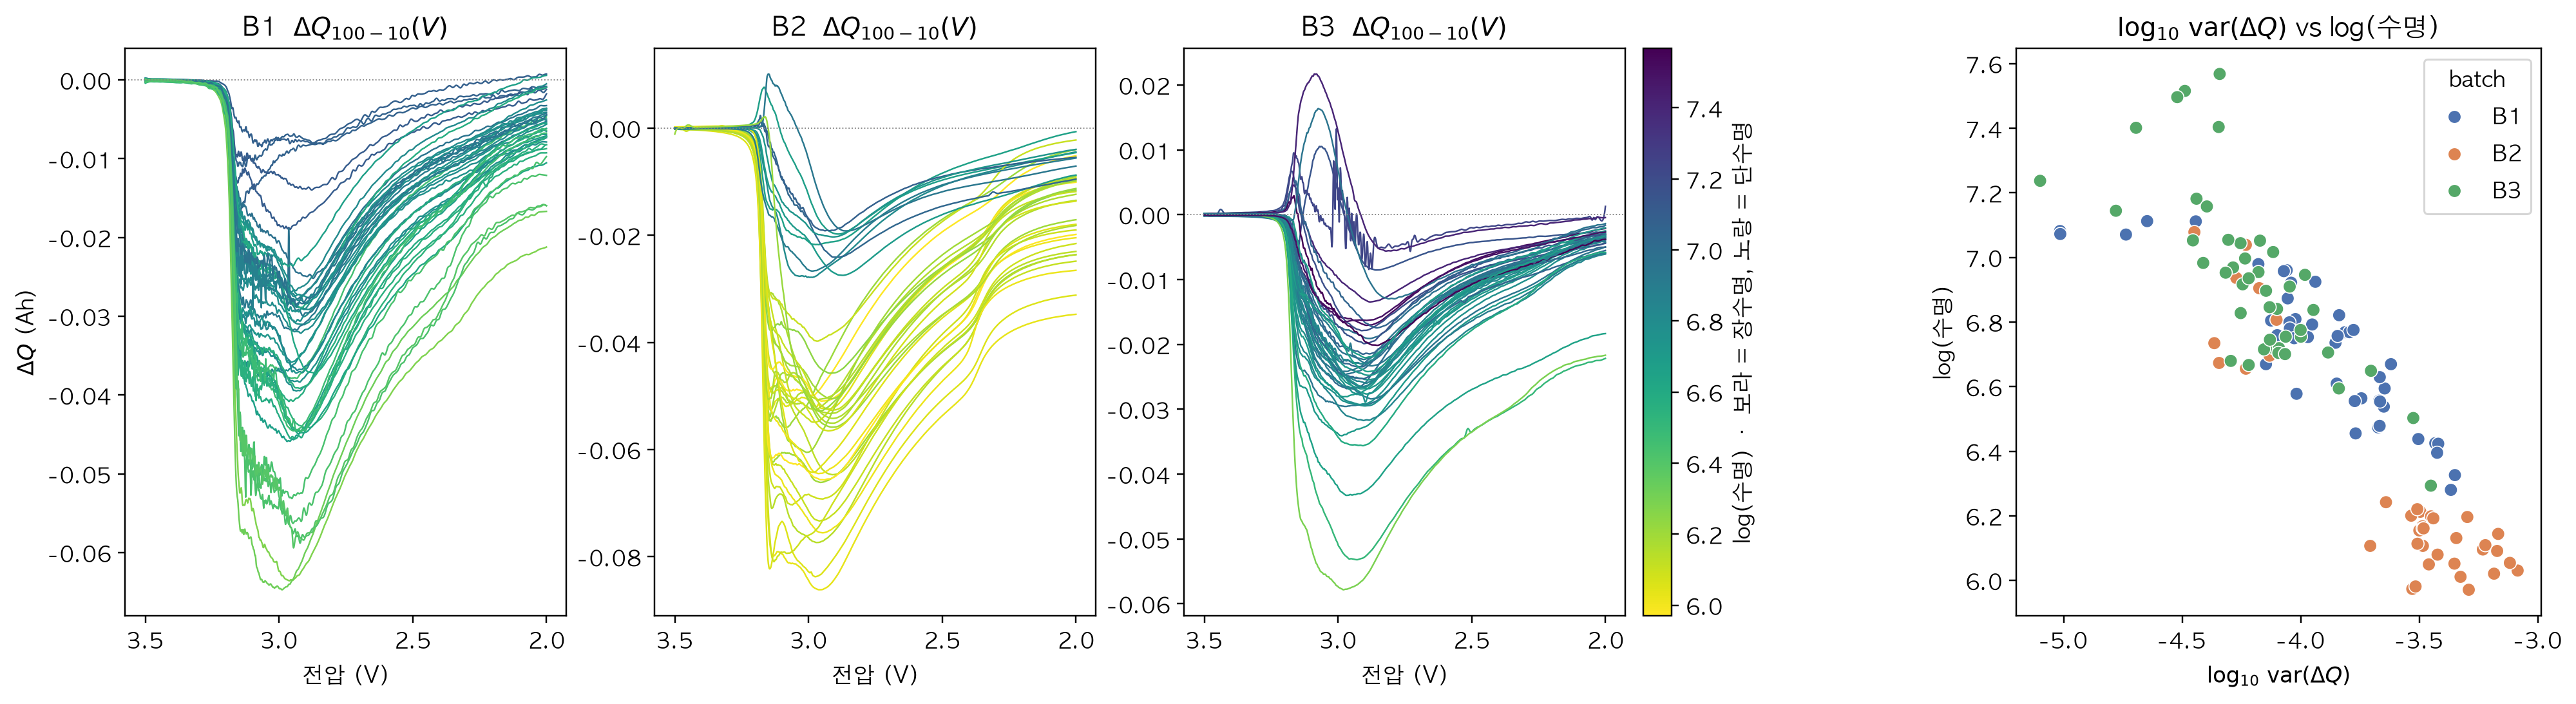

B1 {'dQ_logvar': np.float64(-0.868), 'dQ_logmin': np.float64(-0.858), 'dQ_mean': np.float64(0.872), 'dQ_skew': np.float64(-0.584)}
B2 {'dQ_logvar': np.float64(-0.918), 'dQ_logmin': np.float64(-0.901), 'dQ_mean': np.float64(0.791), 'dQ_skew': np.float64(-0.126)}
B3 {'dQ_logvar': np.float64(-0.762), 'dQ_logmin': np.float64(-0.744), 'dQ_mean': np.float64(0.72), 'dQ_skew': np.float64(0.188)}


In [23]:
from scipy.stats import skew, kurtosis

CYCLES = (4, 5, 10, 100)

def load_qdlin(batch_name, path, keep):
    out = {}
    with h5py.File(path, "r") as f:
        b = f["batch"]
        V = f[b["Vdlin"][0, 0]][()].ravel()
        for i in range(b["cycles"].shape[0]):
            cid = f"{batch_name}_{i:02d}"
            if cid not in keep:
                continue
            c = f[b["cycles"][i, 0]]
            out[cid] = {cyc: f[c["Qdlin"][cyc - 1, 0]][()].ravel() for cyc in CYCLES}
    return out, V

def dq_feats(dq, p):
    return {f"{p}_logvar": np.log10(np.var(dq)), f"{p}_logmin": np.log10(abs(dq.min())),
            f"{p}_mean": dq.mean(), f"{p}_skew": skew(dq), f"{p}_kurt": kurtosis(dq)}

# ① Qdlin 불러오기 (이미 있으면 건너뜀)
if "Q" not in globals() or len(Q) != len(cells):
    Q = {}
    for b, p in BATCH_FILES.items():
        d, V = load_qdlin(b, p, set(cells.cell_id))
        Q.update(d)
print("셀 수:", len(Q))

# ② ΔQ 피처: 기존 dQ 열(+ _x/_y 찌꺼기)을 지우고 다시 붙이기 → 몇 번 실행해도 안전
dqf = pd.DataFrame([
    {"cell_id": cid, **dq_feats(d[100] - d[10], "dQ"), **dq_feats(d[5] - d[4], "dQ54")}
    for cid, d in Q.items()
])
cells = cells.drop(columns=[c for c in cells.columns if c.startswith("dQ")]).merge(dqf, on="cell_id")

# ③ 그래프
fig, axes = plt.subplots(1, 4, figsize=(22, 5.2))
for ax, b in zip(axes[:3], ["B1", "B2", "B3"]):
    for cid in cells.loc[cells.batch == b, "cell_id"]:
        ax.plot(V, Q[cid][100] - Q[cid][10], color=cmap(norm(life[cid])), lw=.8)
    ax.axhline(0, color="gray", lw=.6, ls=":")
    ax.set_title(rf"{b}  $\Delta Q_{{100-10}}(V)$", fontsize=13)
    ax.set_xlabel("전압 (V)")
    ax.invert_xaxis()
axes[0].set_ylabel(r"$\Delta Q$ (Ah)")
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes[:3], pad=.01)
cbar.set_label("log(수명)  ·  보라 = 장수명, 노랑 = 단수명")

sns.scatterplot(data=cells, x="dQ_logvar", y="log_life", hue="batch",
                palette=colors, s=45, ax=axes[3])
axes[3].set_title(r"$\log_{10}\,\mathrm{var}(\Delta Q)$ vs log(수명)", fontsize=13)
axes[3].set_xlabel(r"$\log_{10}\,\mathrm{var}(\Delta Q)$")
axes[3].set_ylabel("log(수명)")
plt.show()

# ④ 배치별 상관
for b, g in cells.groupby("batch"):
    print(b, {c: round(g[c].corr(g.log_life), 3) for c in ["dQ_logvar", "dQ_logmin", "dQ_mean", "dQ_skew"]})

Lesson 5. Q4 C-rate

🧒 5.6C(26%)-4.5C = "0→26%까지 5.6배속, 26→80%까지 4.5배속, 그 뒤는 모두 1배속"이에요.

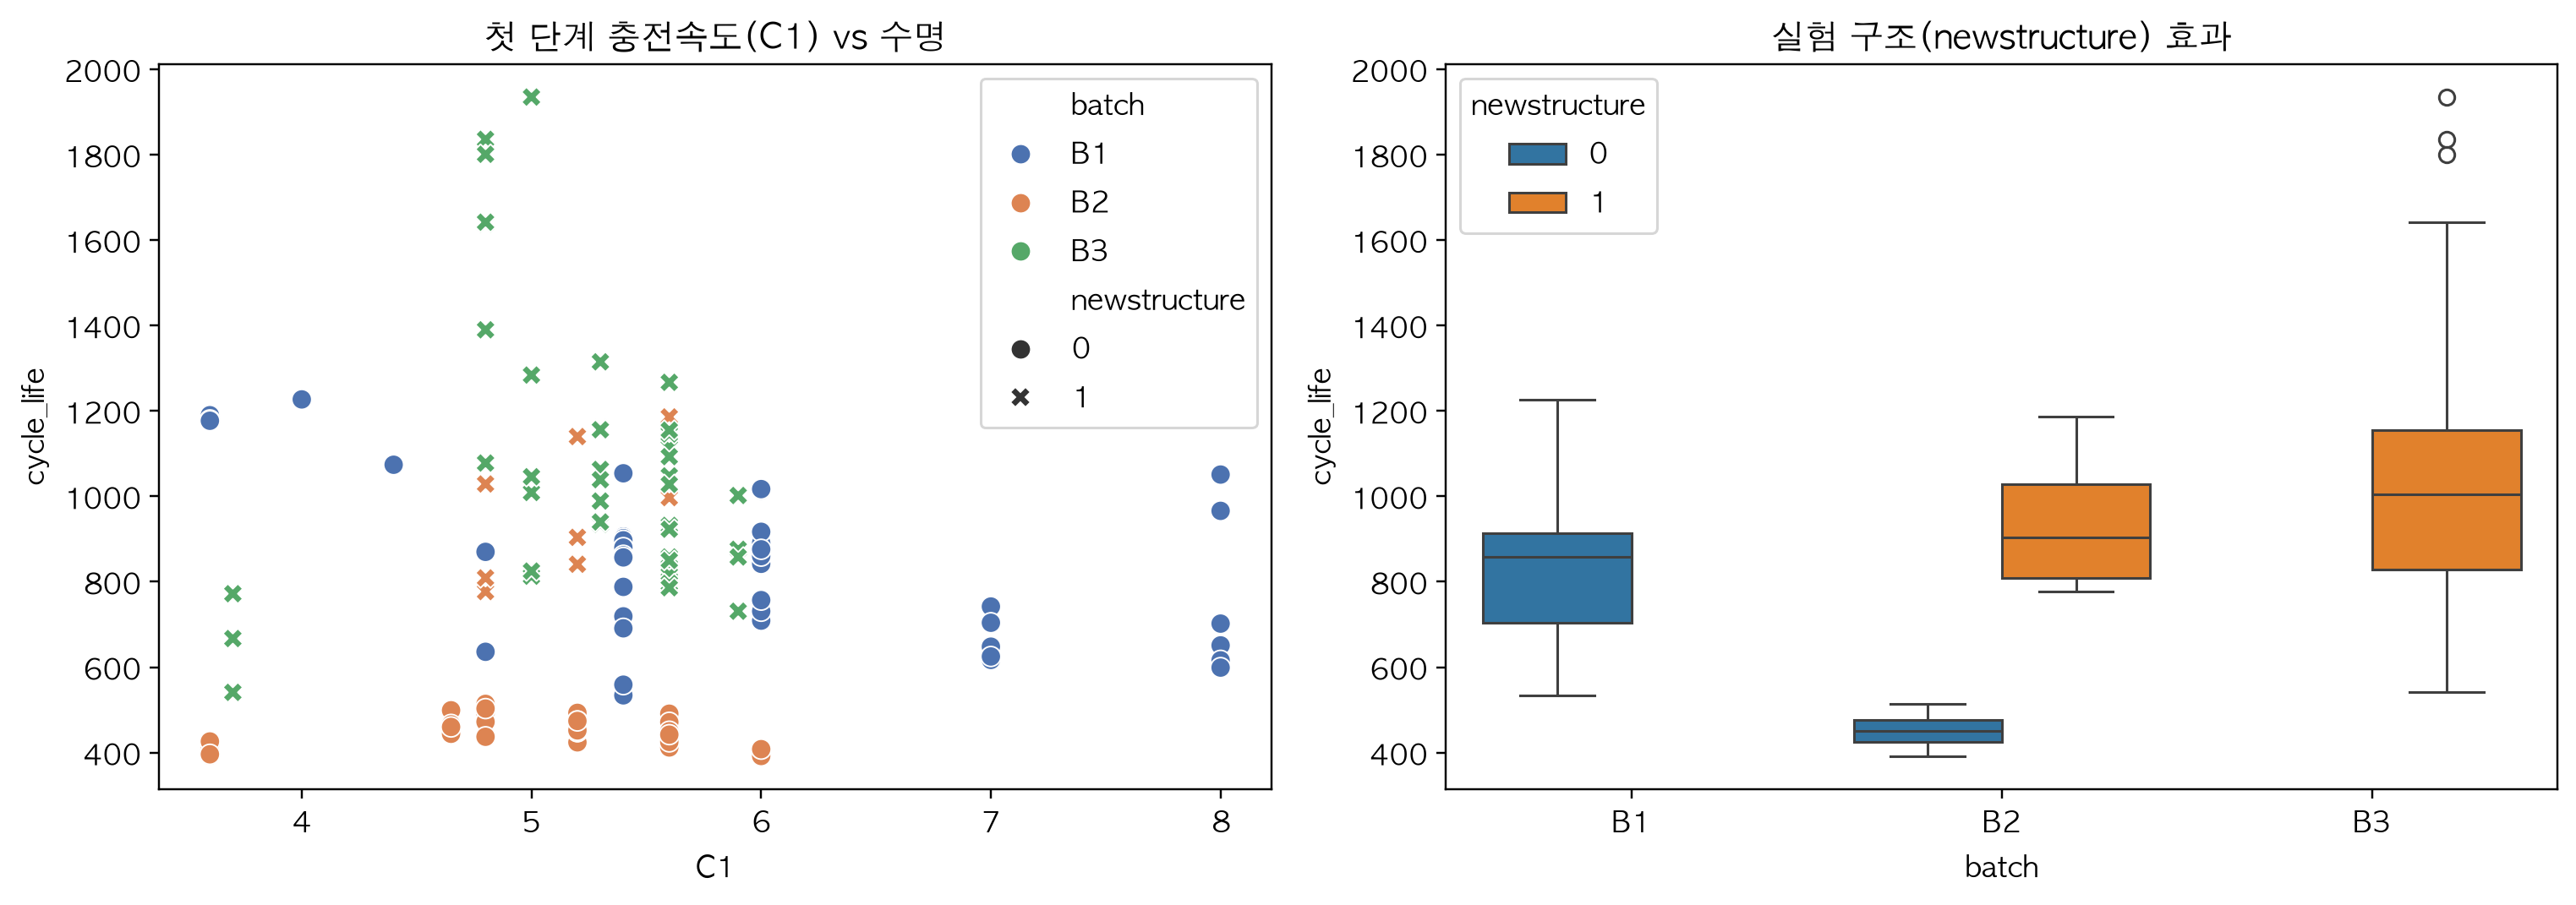

배치 안에서 얼마나 다양한가 (표준편차)
         C1  avgC
batch            
B1     1.20  0.41
B2     0.61  0.00
B3     0.54  0.00

B1 상관: C1 = -0.552 | avgC = -0.734


In [24]:
import re
pat = re.compile(r"([\d.]+)C\((\d+)%\)-([\d.]+)C")

def parse_policy(p):
    m = pat.match(p)
    return pd.Series({"C1": float(m[1]), "Q1": float(m[2]), "C2": float(m[3])})

# 기존 열 지우고 다시 만들기
pol_cols = ["C1", "Q1", "C2", "newstructure", "avgC"]
cells = cells.drop(columns=[c for c in cells.columns if c in pol_cols or c.split("_")[0] in pol_cols and c.endswith(("_x", "_y"))])
cells = cells.join(cells.policy.apply(parse_policy))
cells["newstructure"] = cells.policy.str.contains("newstructure").astype(int)
t_to80 = cells.Q1/100/cells.C1 + (80 - cells.Q1).clip(lower=0)/100/cells.C2
cells["avgC"] = 0.8 / t_to80

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=cells, x="C1", y="cycle_life", hue="batch", style="newstructure",
                palette=colors, s=60, ax=axes[0])
axes[0].set_title("첫 단계 충전속도(C1) vs 수명")
sns.boxplot(data=cells, x="batch", y="cycle_life", hue="newstructure", ax=axes[1])
axes[1].set_title("실험 구조(newstructure) 효과")
plt.tight_layout(); plt.show()

print("배치 안에서 얼마나 다양한가 (표준편차)")
print(cells.groupby("batch")[["C1", "avgC"]].std().round(2))
b1 = cells[cells.batch == "B1"]
print("\nB1 상관: C1 =", round(b1.C1.corr(b1.log_life), 3), "| avgC =", round(b1.avgC.corr(b1.log_life), 3))

Lesson 6. Feature Engineering + Q5 상관관계

🧒 VIF = "이 피처가 다른 피처들로 얼마나 흉내 내지는가". 10 넘으면 쌍둥이가 있다는 뜻이에요.
KS 검정 = "B1과 B2(또는 B3)에서 이 피처의 분포가 얼마나 다른가". 0~1 사이로, 1에 가까울수록 딴판이에요.

_x/_y 남은 열: []


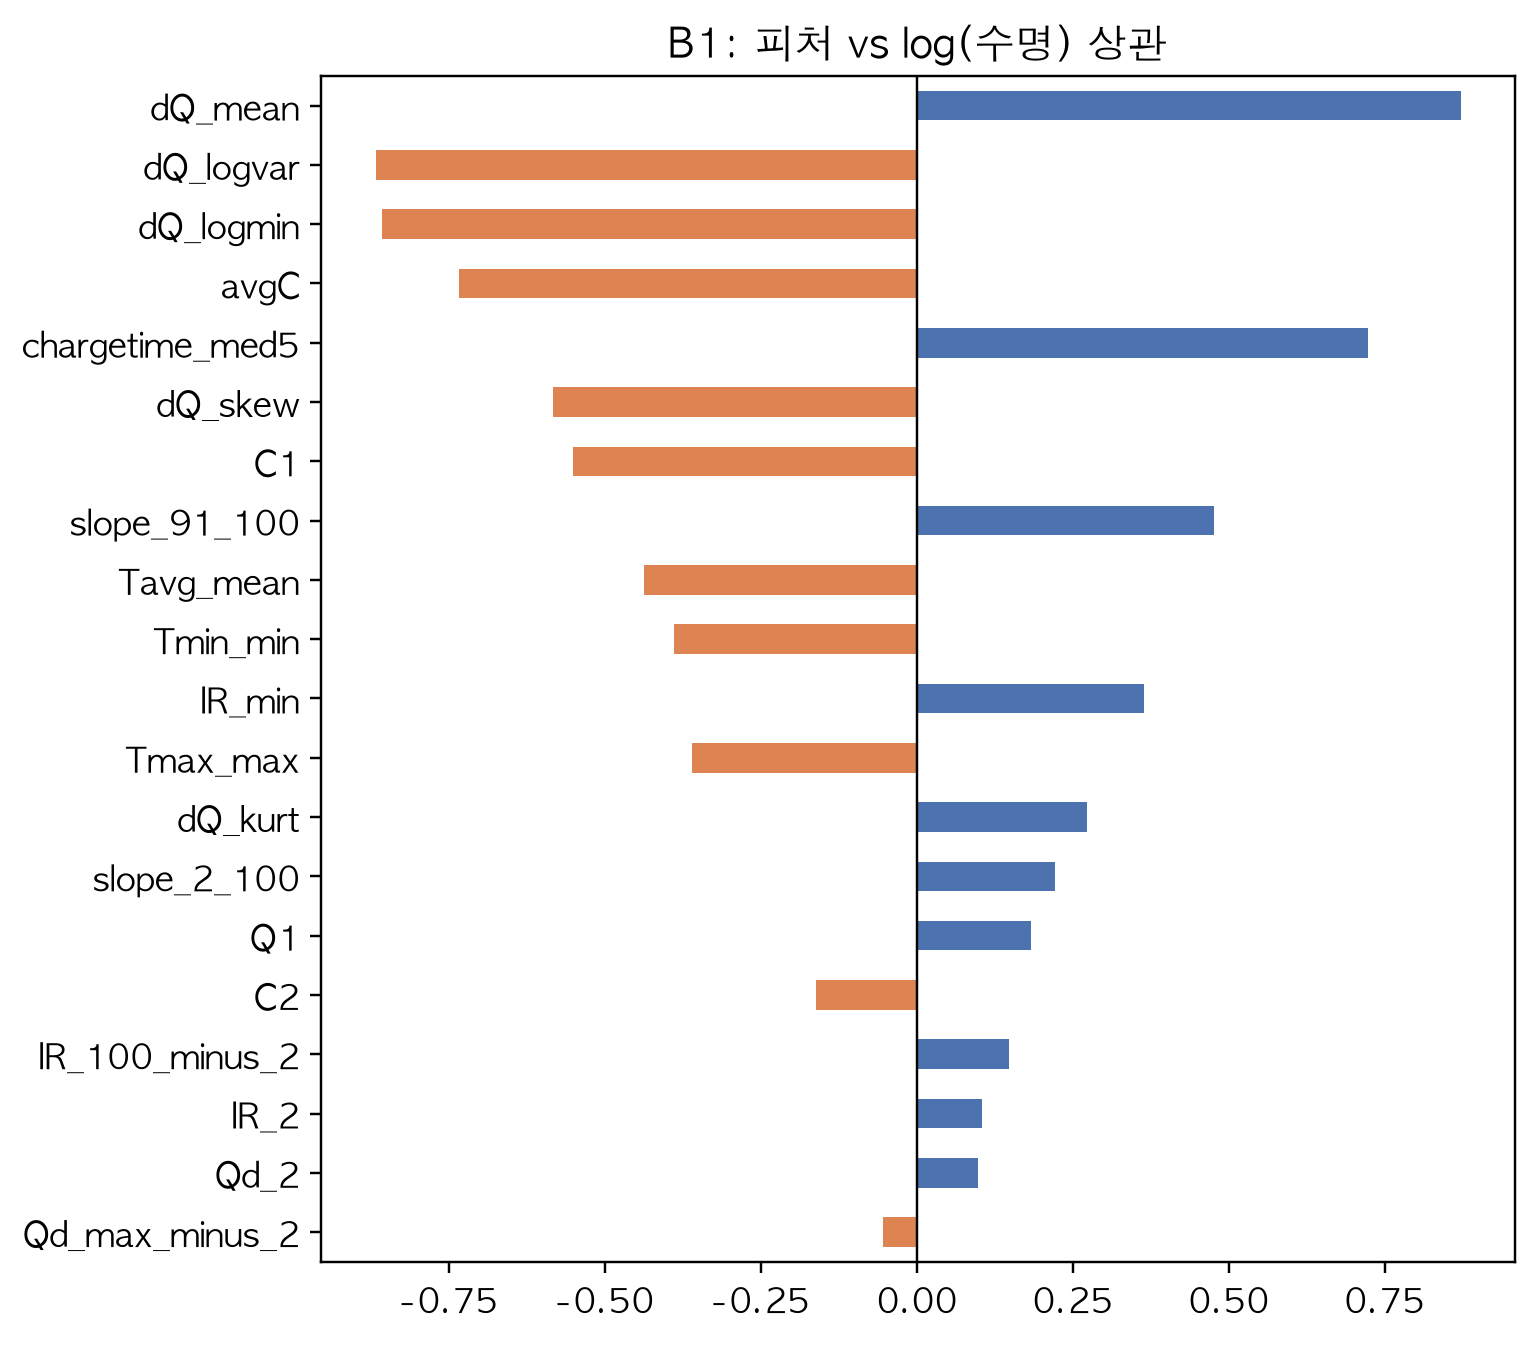

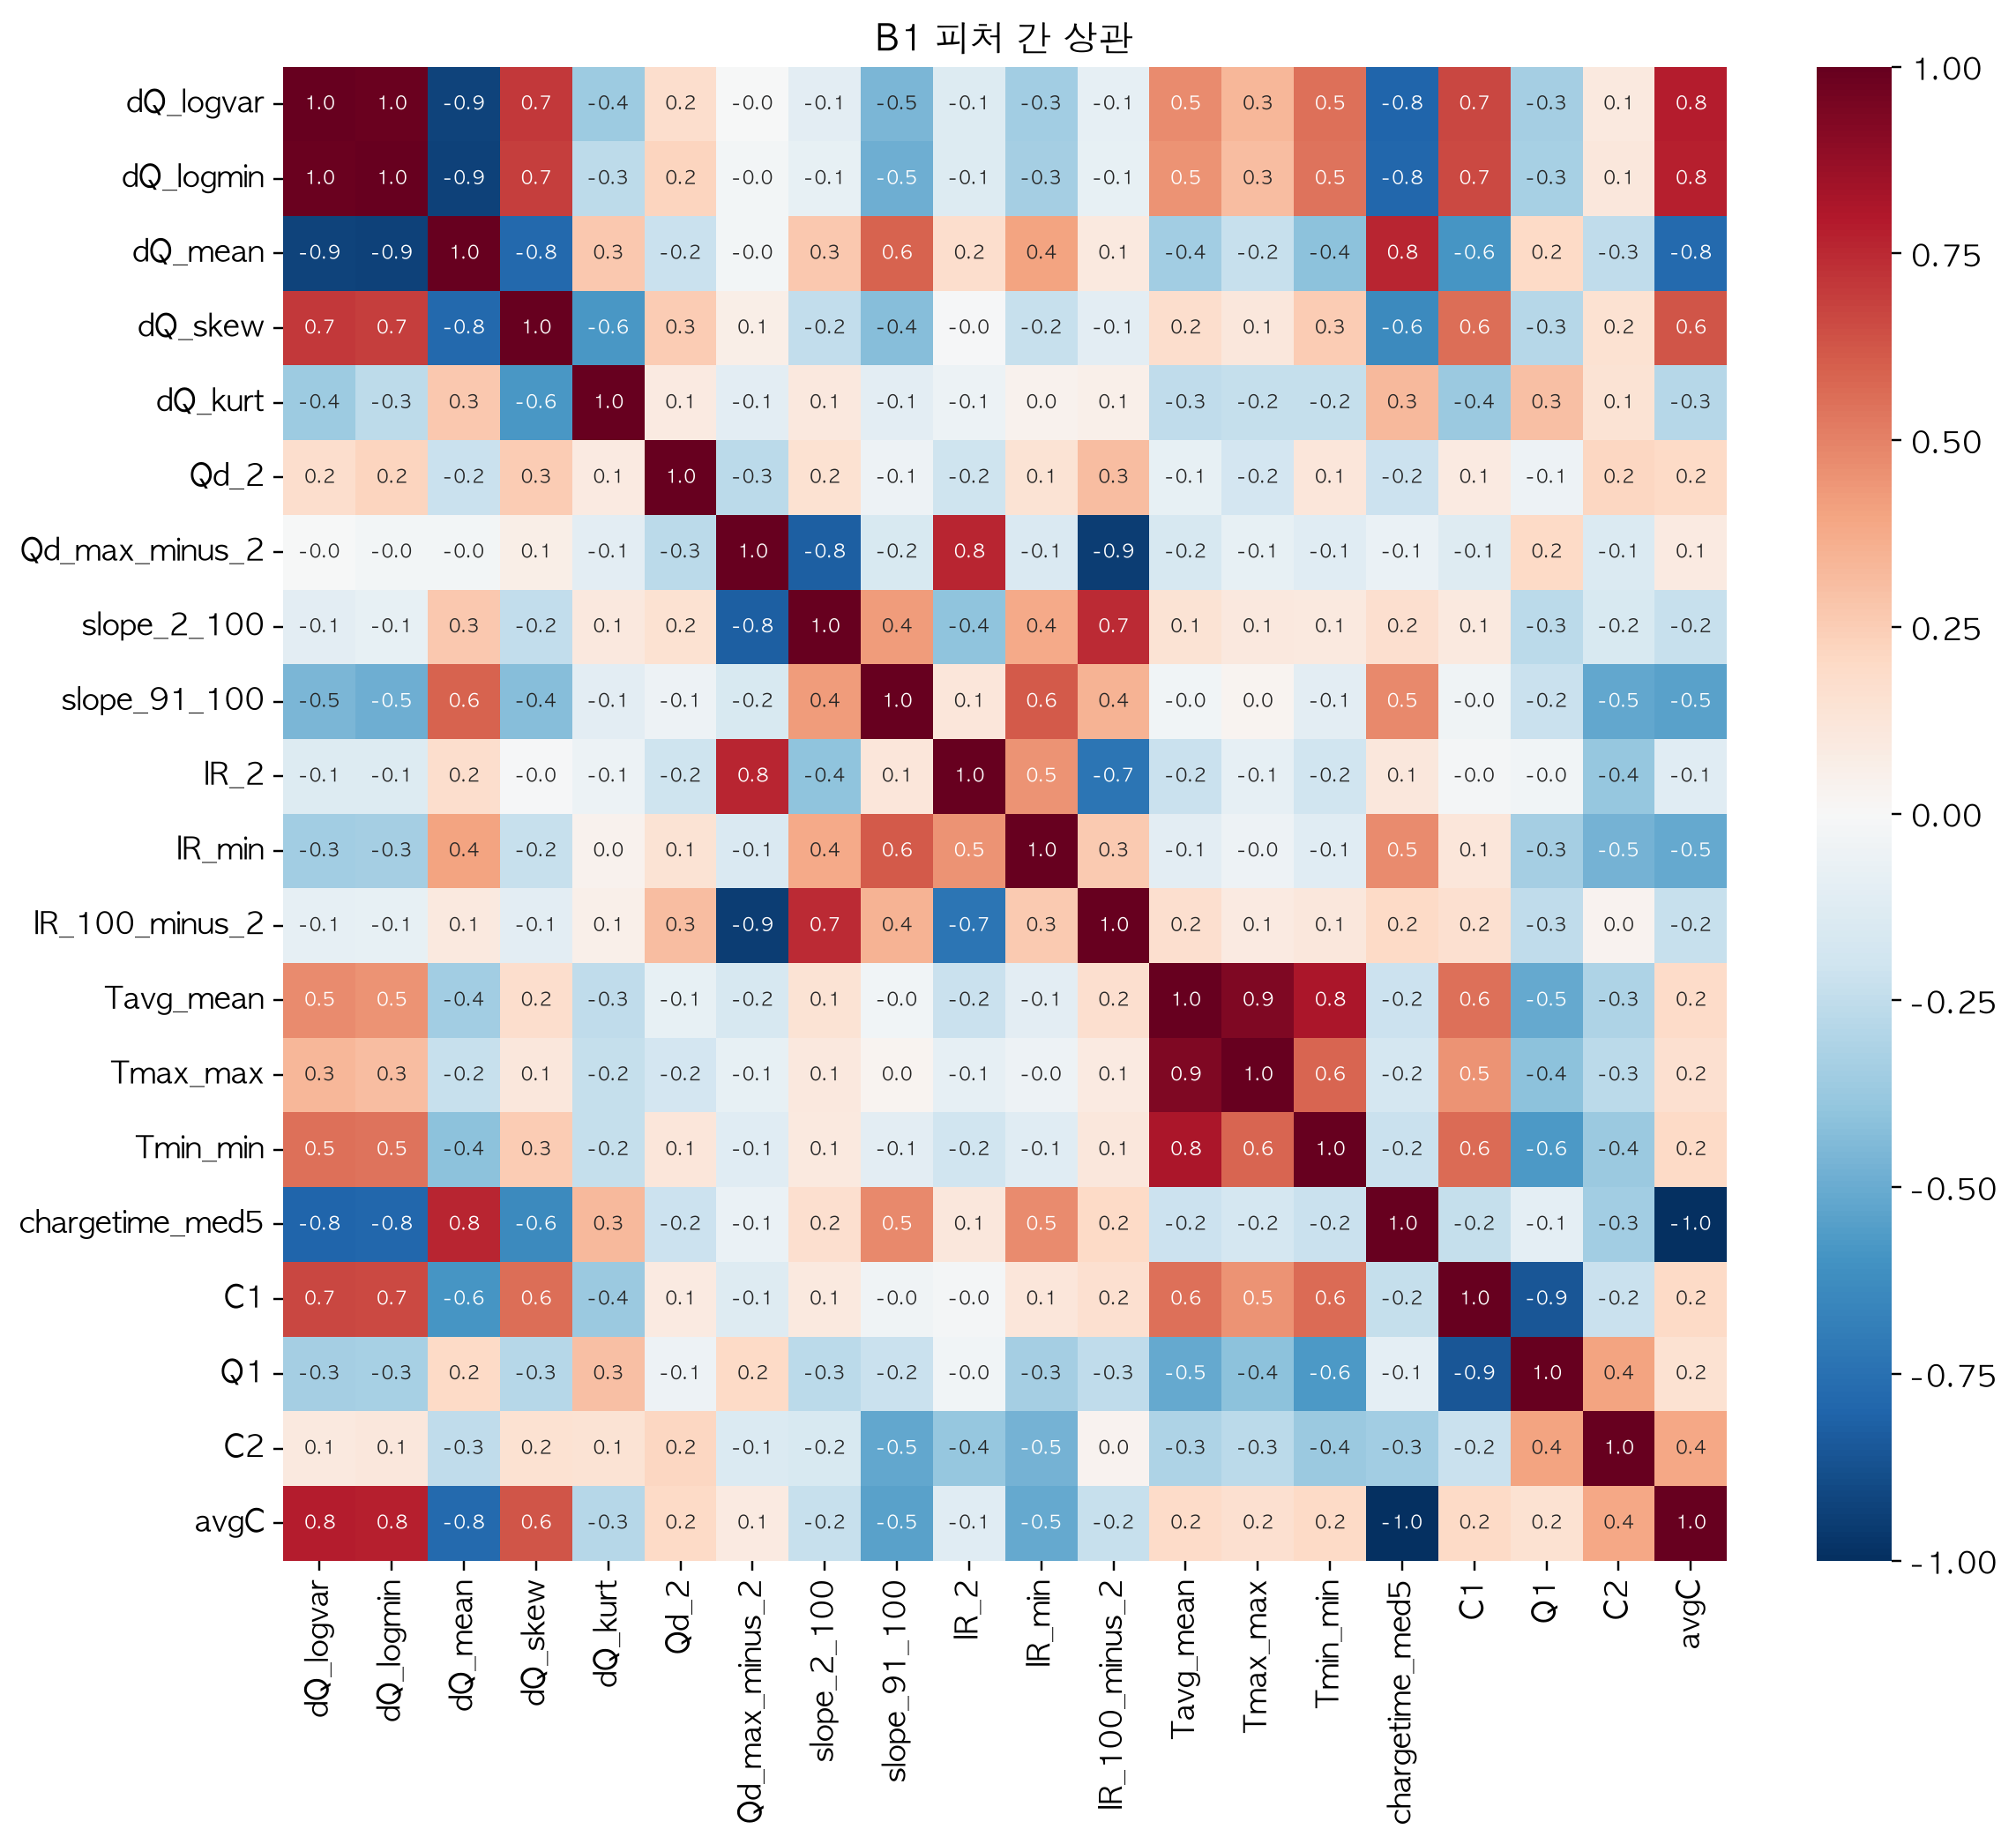

VIF
 dQ_logvar       73.7
dQ_logmin       80.0
slope_91_100     1.7
Qd_2             1.3
IR_2             1.2
Tavg_mean        1.7
C1               2.5
dtype: float64
                 KS_B2  KS_B3
IR_min            0.25   0.91
IR_2              0.35   0.89
Tmin_min          0.19   0.89
C2                0.80   0.80
Qd_2              0.76   0.80
chargetime_med5   0.72   0.75
avgC              0.74   0.74
Tavg_mean         0.22   0.59
Qd_max_minus_2    0.30   0.58
IR_100_minus_2    0.42   0.58
dQ_logvar         0.59   0.56
dQ_logmin         0.59   0.55
dQ_kurt           0.30   0.55
dQ_mean           0.56   0.53
C1                0.54   0.52
slope_91_100      0.60   0.46
Tmax_max          0.21   0.31
slope_2_100       0.44   0.26
Q1                0.20   0.26
dQ_skew           0.49   0.17
저장 완료 ✅


In [25]:
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

e = df[(df.cycle >= 2) & (df.cycle <= 100)].copy()
e.loc[e.IR == 0, "IR"] = np.nan

def fit_slope(g, lo, hi):
    s = g[(g.cycle >= lo) & (g.cycle <= hi)]
    return np.polyfit(s.cycle, s.QDischarge, 1)[0]

feat = e.groupby("cell_id").apply(lambda g: pd.Series({
    "Qd_2": g.loc[g.cycle == 2, "QDischarge"].iloc[0],
    "Qd_max_minus_2": g.QDischarge.max() - g.loc[g.cycle == 2, "QDischarge"].iloc[0],
    "slope_2_100": fit_slope(g, 2, 100),
    "slope_91_100": fit_slope(g, 91, 100),
    "IR_2": g.loc[g.cycle == 2, "IR"].iloc[0],
    "IR_min": g.IR.min(),
    "IR_100_minus_2": g.loc[g.cycle == 100, "IR"].iloc[0] - g.loc[g.cycle == 2, "IR"].iloc[0],
    "Tavg_mean": g.Tavg.mean(), "Tmax_max": g.Tmax.max(), "Tmin_min": g.Tmin.min(),
    "chargetime_med5": g[g.cycle <= 6].chargetime.median(),
})).reset_index()

# 겹치는 열(+ _x/_y 찌꺼기) 빼고 합치기
base = [c.rsplit("_", 1)[0] if c.endswith(("_x", "_y")) else c for c in cells.columns]
drop = [c for c, bname in zip(cells.columns, base) if bname in feat.columns and c != "cell_id"]
X = cells.drop(columns=drop).merge(feat, on="cell_id")
print("_x/_y 남은 열:", [c for c in X.columns if c.endswith(("_x", "_y"))])   # [] 이면 OK

FEATS = ["dQ_logvar", "dQ_logmin", "dQ_mean", "dQ_skew", "dQ_kurt",
         "Qd_2", "Qd_max_minus_2", "slope_2_100", "slope_91_100",
         "IR_2", "IR_min", "IR_100_minus_2", "Tavg_mean", "Tmax_max", "Tmin_min",
         "chargetime_med5", "C1", "Q1", "C2", "avgC"]
b1 = X[X.batch == "B1"]          # 선택 기준은 B1(학습)에서만!

# ① 상관 순위
corr = pd.DataFrame({"pearson": b1[FEATS].corrwith(b1.log_life),
                     "spearman": b1[FEATS].corrwith(b1.log_life, method="spearman")})
corr = corr.reindex(corr.pearson.abs().sort_values(ascending=False).index).round(3)
fig, ax = plt.subplots(figsize=(7, 7))
corr["pearson"].plot.barh(ax=ax, color=np.where(corr.pearson > 0, "#4C72B0", "#DD8452"))
ax.invert_yaxis(); ax.axvline(0, color="k", lw=.8); ax.set_title("B1: 피처 vs log(수명) 상관")
plt.show()

# ② 피처 간 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(b1[FEATS].corr(), cmap="RdBu_r", vmin=-1, vmax=1, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("B1 피처 간 상관"); plt.show()

# ③ VIF
cand = ["dQ_logvar", "dQ_logmin", "slope_91_100", "Qd_2", "IR_2", "Tavg_mean", "C1"]
A = add_constant(b1[cand].dropna())
vif = pd.Series({c: variance_inflation_factor(A.values, i) for i, c in enumerate(A.columns) if c != "const"})
print("VIF\n", vif.round(1))

# ④ B1 vs 테스트 분포 차이 (KS)
ks = pd.DataFrame({f"KS_{b}": [ks_2samp(b1[c].dropna(), X.loc[X.batch == b, c].dropna()).statistic
                               for c in FEATS] for b in ["B2", "B3"]}, index=FEATS).round(2)
print(ks.sort_values("KS_B3", ascending=False))

X.to_parquet("processed/features.parquet", index=False)
print("저장 완료 ✅")